# 03 Ablation 1: Class Imbalance Strategy

**Research question**: Which class imbalance handling strategy maximizes
per-class Recall on the UNSW-NB15 multiclass classification task?

**Design**:
- Model: Random Forest (fixed)
- Encoding: Label Encoding (fixed, baseline)
- Variable: class imbalance strategy (5 conditions)
- Train/test split: loaded from baseline processed files

**Strategies compared**:
1. None (baseline)
2. class_weight='balanced'
3. Random Oversampling
4. Random Undersampling
5. SMOTE

**Primary metric**: Per-class Recall  
**Secondary metrics**: Macro F1, Confusion Matrix

> **Note on sampling cap**: RandomOverSampler and SMOTE are capped at
> `min(2nd-largest-class-count, 50 000)` per minority class to avoid
> MemoryError on the full UNSW-NB15 dataset (~2 M training rows).
> RandomUnderSampler reduces only the majority class (Normal) to the
> same cap, preserving all minority samples.

In [1]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from imblearn.over_sampling import RandomOverSampler, SMOTE
from imblearn.under_sampling import RandomUnderSampler

PROJECT_ROOT = Path('..')
PROCESSED_DIR = PROJECT_ROOT / 'data' / 'processed'
OUTPUT_DIR = PROJECT_ROOT / 'data' / 'outputs'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42

In [2]:
X_train = pd.read_csv(PROCESSED_DIR / 'X_train_baseline.csv')
X_test  = pd.read_csv(PROCESSED_DIR / 'X_test_baseline.csv')
y_train = pd.read_csv(PROCESSED_DIR / 'y_train_baseline.csv').squeeze()
y_test  = pd.read_csv(PROCESSED_DIR / 'y_test_baseline.csv').squeeze()

print('X_train:', X_train.shape)
print('X_test:', X_test.shape)
print('Class distribution (train):')
print(y_train.value_counts())

X_train: (2032037, 43)
X_test: (508010, 43)
Class distribution (train):
attack_cat
Normal            1775011
Generic            172385
Exploits            35620
Fuzzers             19397
DoS                 13082
Reconnaissance      11189
Analysis             2142
Backdoor             1863
Shellcode            1209
Worms                 139
Name: count, dtype: int64


In [3]:
# Categorical columns to encode
categorical_cols = ['sport', 'dsport', 'proto', 'state', 'service', 'ct_ftp_cmd']

# Fit LabelEncoders on training data only, apply to both train and test
le_dict = {}
X_train_enc = X_train.copy()
X_test_enc  = X_test.copy()

for col in categorical_cols:
    le = LabelEncoder()
    X_train_enc[col] = le.fit_transform(X_train_enc[col].astype(str))
    # Handle unseen labels in test set
    le_classes = set(le.classes_)
    X_test_enc[col] = X_test_enc[col].astype(str).apply(
        lambda x: x if x in le_classes else le.classes_[0]
    )
    X_test_enc[col] = le.transform(X_test_enc[col])
    le_dict[col] = le

print('Label encoding applied to:', categorical_cols)
print('X_train_enc shape:', X_train_enc.shape)

Label encoding applied to: ['sport', 'dsport', 'proto', 'state', 'service', 'ct_ftp_cmd']
X_train_enc shape: (2032037, 43)


In [4]:
def run_experiment(X_tr, y_tr, X_te, y_te, strategy_name, class_weight=None):
    """
    Train RF with given data and class_weight setting.
    Returns per-class recall dict and macro F1.
    """
    clf = RandomForestClassifier(
        n_estimators=100,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        class_weight=class_weight
    )
    clf.fit(X_tr, y_tr)
    y_pred = clf.predict(X_te)

    report = classification_report(y_te, y_pred, output_dict=True, zero_division=0)
    macro_f1 = f1_score(y_te, y_pred, average='macro', zero_division=0)

    print(f"\n{'='*50}")
    print(f"Strategy: {strategy_name}")
    print(f"{'='*50}")
    print(classification_report(y_te, y_pred, zero_division=0))

    return report, macro_f1, clf

In [5]:
results = {}

# ---- Sampling strategy parameters ----
class_counts = y_train.value_counts()
majority_class = class_counts.idxmax()
second_largest = int(class_counts.sort_values(ascending=False).iloc[1])

# Cap oversampling to avoid MemoryError (5+ GiB) on full UNSW-NB15 dataset.
# We oversample each minority class up to min(2nd-largest-count, 50000),
# leaving the majority class (Normal) untouched.
OVERSAMPLE_CAP = min(second_largest, 50000)
print(f'Majority class : {majority_class} ({class_counts[majority_class]:,} samples)')
print(f'Oversample cap : {OVERSAMPLE_CAP:,} samples per minority class')

# ---- 1. None (Baseline) ----
report, macro_f1, _ = run_experiment(
    X_train_enc, y_train, X_test_enc, y_test,
    strategy_name='None (Baseline)'
)
results['None'] = {'report': report, 'macro_f1': macro_f1}

# ---- 2. class_weight='balanced' ----
report, macro_f1, _ = run_experiment(
    X_train_enc, y_train, X_test_enc, y_test,
    strategy_name='class_weight=balanced',
    class_weight='balanced'
)
results['class_weight'] = {'report': report, 'macro_f1': macro_f1}

# ---- 3. Random Oversampling (capped) ----
# Oversample minority classes to OVERSAMPLE_CAP; majority class unchanged.
ros_strategy = {
    cls: OVERSAMPLE_CAP
    for cls, cnt in class_counts.items()
    if cls != majority_class and cnt < OVERSAMPLE_CAP
}
ros = RandomOverSampler(sampling_strategy=ros_strategy, random_state=RANDOM_STATE)
X_ros, y_ros = ros.fit_resample(X_train_enc, y_train)
print(f'\nRandomOverSampling: {X_train_enc.shape[0]:,} -> {X_ros.shape[0]:,} samples')
report, macro_f1, _ = run_experiment(
    X_ros, y_ros, X_test_enc, y_test,
    strategy_name='Random Oversampling'
)
results['RandomOverSampling'] = {'report': report, 'macro_f1': macro_f1}

# ---- 4. Random Undersampling (majority -> 2nd-largest, minorities intact) ----
rus_strategy = {
    cls: (second_largest if cls == majority_class else int(cnt))
    for cls, cnt in class_counts.items()
}
rus = RandomUnderSampler(sampling_strategy=rus_strategy, random_state=RANDOM_STATE)
X_rus, y_rus = rus.fit_resample(X_train_enc, y_train)
print(f'\nRandomUnderSampling: {X_train_enc.shape[0]:,} -> {X_rus.shape[0]:,} samples')
report, macro_f1, _ = run_experiment(
    X_rus, y_rus, X_test_enc, y_test,
    strategy_name='Random Undersampling'
)
results['RandomUnderSampling'] = {'report': report, 'macro_f1': macro_f1}

# ---- 5. SMOTE (capped — same logic as ROS) ----
min_count = class_counts.min()
k_neighbors = min(5, min_count - 1)
smote_strategy = {
    cls: OVERSAMPLE_CAP
    for cls, cnt in class_counts.items()
    if cls != majority_class and cnt < OVERSAMPLE_CAP
}
smote = SMOTE(
    sampling_strategy=smote_strategy,
    random_state=RANDOM_STATE,
    k_neighbors=k_neighbors
)
X_smote, y_smote = smote.fit_resample(X_train_enc, y_train)
print(f'\nSMOTE: {X_train_enc.shape[0]:,} -> {X_smote.shape[0]:,} samples')
report, macro_f1, _ = run_experiment(
    X_smote, y_smote, X_test_enc, y_test,
    strategy_name='SMOTE'
)
results['SMOTE'] = {'report': report, 'macro_f1': macro_f1}

Majority class : Normal (1,775,011 samples)
Oversample cap : 50,000 samples per minority class



Strategy: None (Baseline)


                precision    recall  f1-score   support

      Analysis       0.88      0.11      0.20       535
      Backdoor       0.54      0.07      0.12       466
           DoS       0.34      0.26      0.29      3271
      Exploits       0.64      0.83      0.72      8905
       Fuzzers       0.70      0.60      0.65      4849
       Generic       1.00      0.99      0.99     43096
        Normal       1.00      1.00      1.00    443753
Reconnaissance       0.93      0.76      0.84      2798
     Shellcode       0.69      0.79      0.74       302
         Worms       0.67      0.23      0.34        35

      accuracy                           0.98    508010
     macro avg       0.74      0.56      0.59    508010
  weighted avg       0.98      0.98      0.98    508010




Strategy: class_weight=balanced


                precision    recall  f1-score   support

      Analysis       0.06      0.13      0.08       535
      Backdoor       0.03      0.12      0.04       466
           DoS       0.31      0.46      0.37      3271
      Exploits       0.83      0.59      0.69      8905
       Fuzzers       0.76      0.55      0.64      4849
       Generic       1.00      0.99      0.99     43096
        Normal       1.00      1.00      1.00    443753
Reconnaissance       0.93      0.76      0.83      2798
     Shellcode       0.71      0.81      0.76       302
         Worms       0.69      0.51      0.59        35

      accuracy                           0.98    508010
     macro avg       0.63      0.59      0.60    508010
  weighted avg       0.98      0.98      0.98    508010



...


Strategy: Random Undersampling


                precision    recall  f1-score   support

      Analysis       0.23      0.17      0.19       535
      Backdoor       0.58      0.07      0.12       466
           DoS       0.34      0.26      0.30      3271
      Exploits       0.62      0.84      0.71      8905
       Fuzzers       0.44      0.88      0.59      4849
       Generic       1.00      0.99      0.99     43096
        Normal       1.00      0.99      0.99    443753
Reconnaissance       0.93      0.76      0.84      2798
     Shellcode       0.71      0.79      0.75       302
         Worms       0.67      0.23      0.34        35

      accuracy                           0.98    508010
     macro avg       0.65      0.60      0.58    508010
  weighted avg       0.98      0.98      0.98    508010




SMOTE: 2,032,037 -> 2,347,396 samples



Strategy: SMOTE


                precision    recall  f1-score   support

      Analysis       0.09      0.17      0.12       535
      Backdoor       0.05      0.11      0.07       466
           DoS       0.34      0.53      0.41      3271
      Exploits       0.78      0.62      0.69      8905
       Fuzzers       0.67      0.66      0.67      4849
       Generic       1.00      0.99      0.99     43096
        Normal       1.00      1.00      1.00    443753
Reconnaissance       0.89      0.78      0.83      2798
     Shellcode       0.59      0.92      0.72       302
         Worms       0.44      0.60      0.51        35

      accuracy                           0.98    508010
     macro avg       0.58      0.64      0.60    508010
  weighted avg       0.98      0.98      0.98    508010



In [6]:
classes = sorted(y_test.unique())
strategy_names = list(results.keys())

# Build recall table
rows = []
for cls in classes:
    row = {'class': cls}
    for strategy in strategy_names:
        recall = results[strategy]['report'].get(cls, {}).get('recall', 0.0)
        row[strategy] = round(recall, 4)
    rows.append(row)

# Add macro F1 row
macro_row = {'class': 'Macro F1'}
for strategy in strategy_names:
    macro_row[strategy] = round(results[strategy]['macro_f1'], 4)
rows.append(macro_row)

summary_df = pd.DataFrame(rows).set_index('class')
print('\nRecall per class and Macro F1 across strategies:')
print(summary_df.to_string())

# Save
summary_df.to_csv(OUTPUT_DIR / 'ablation1_class_imbalance_results.csv')
print('\nSaved to data/outputs/ablation1_class_imbalance_results.csv')


Recall per class and Macro F1 across strategies:


                  None  class_weight  RandomOverSampling  RandomUnderSampling   SMOTE
class                                                                                
Analysis        0.1103        0.1252              0.1421               0.1682  0.1720
Backdoor        0.0687        0.1223              0.1245               0.0665  0.1052
DoS             0.2556        0.4570              0.2825               0.2644  0.5307
Exploits        0.8265        0.5945              0.5838               0.8372  0.6179
Fuzzers         0.6007        0.5471              0.6465               0.8785  0.6579
Generic         0.9880        0.9872              0.9874               0.9882  0.9866
Normal          0.9977        0.9980              0.9969               0.9872  0.9967
Reconnaissance  0.7638        0.7566              0.7788               0.7641  0.7781
Shellcode       0.7881        0.8146              0.8675               0.7881  0.9238
Worms           0.2286        0.5143              0.62

In [7]:
# Best strategy = highest average Recall across attack classes (excluding Normal)
attack_classes = [c for c in classes if c != 'Normal']

avg_attack_recall = {}
for strategy in strategy_names:
    recalls = [
        results[strategy]['report'].get(cls, {}).get('recall', 0.0)
        for cls in attack_classes
    ]
    avg_attack_recall[strategy] = round(np.mean(recalls), 4)

best_strategy = max(avg_attack_recall, key=avg_attack_recall.get)

print('Average attack-class Recall per strategy:')
for k, v in sorted(avg_attack_recall.items(), key=lambda x: -x[1]):
    marker = ' <-- BEST' if k == best_strategy else ''
    print(f'  {k}: {v}{marker}')

print(f'\nBest strategy for Ablation 2: {best_strategy}')

Average attack-class Recall per strategy:
  SMOTE: 0.5969 <-- BEST
  RandomOverSampling: 0.5602
  RandomUnderSampling: 0.5538
  class_weight: 0.5465
  None: 0.5145

Best strategy for Ablation 2: SMOTE


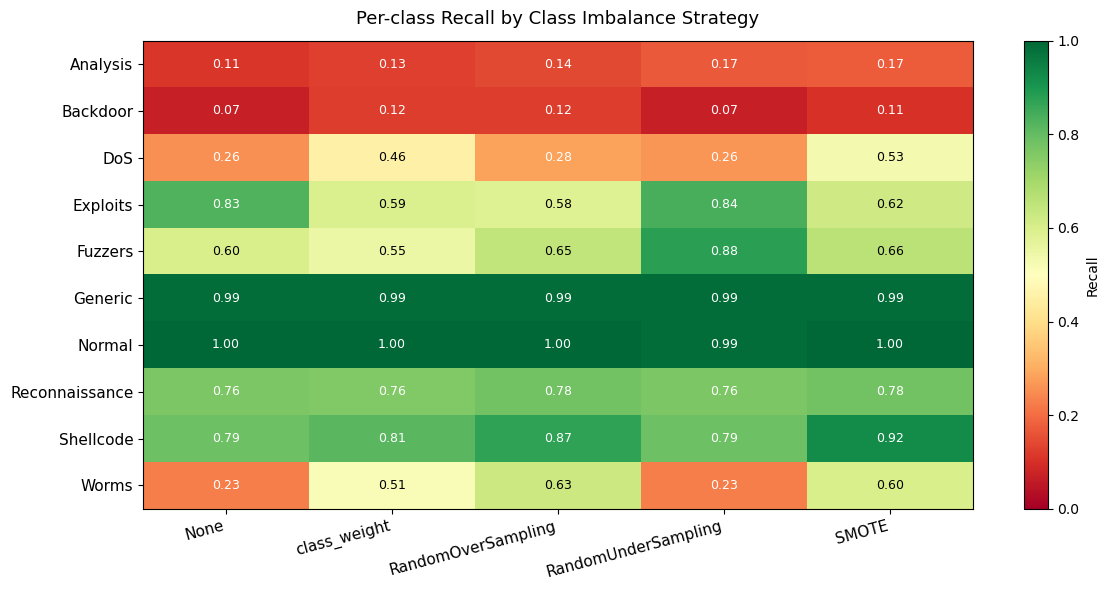

Saved: reports/ablation1_recall_heatmap.png


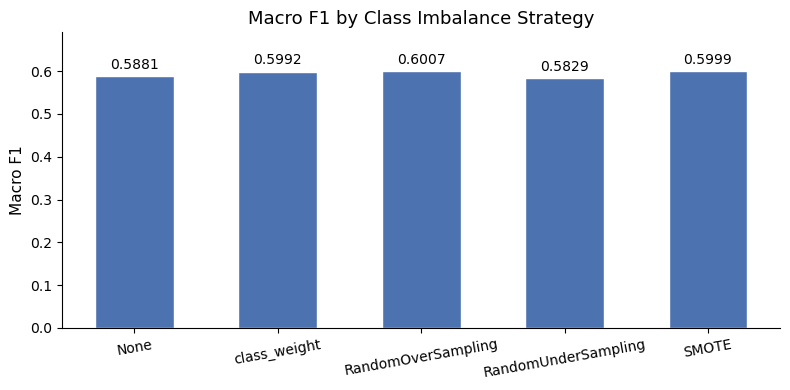

Saved: reports/ablation1_macro_f1.png


In [8]:
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'DejaVu Sans'

FIGURE_DIR = PROJECT_ROOT / 'reports'
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

# --- Figure 1: Recall Heatmap (classes x strategies) ---
recall_data = summary_df.drop(index='Macro F1', errors='ignore')

fig, ax = plt.subplots(figsize=(12, 6))
im = ax.imshow(recall_data.values.astype(float), aspect='auto', cmap='RdYlGn', vmin=0, vmax=1)

ax.set_xticks(range(len(recall_data.columns)))
ax.set_xticklabels(recall_data.columns, fontsize=11, rotation=15, ha='right')
ax.set_yticks(range(len(recall_data.index)))
ax.set_yticklabels(recall_data.index, fontsize=11)

# Annotate each cell
for i in range(len(recall_data.index)):
    for j in range(len(recall_data.columns)):
        val = recall_data.values[i, j]
        color = 'white' if val < 0.35 or val > 0.75 else 'black'
        ax.text(j, i, f'{val:.2f}', ha='center', va='center', fontsize=9, color=color)

plt.colorbar(im, ax=ax, label='Recall')
ax.set_title('Per-class Recall by Class Imbalance Strategy', fontsize=13, pad=12)
plt.tight_layout()
plt.savefig(FIGURE_DIR / 'ablation1_recall_heatmap.png', dpi=200, bbox_inches='tight')
plt.show()
print('Saved: reports/ablation1_recall_heatmap.png')

# --- Figure 2: Macro F1 bar chart ---
macro_vals = {k: v['macro_f1'] for k, v in results.items()}
fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(macro_vals.keys(), macro_vals.values(), color='#4C72B0', edgecolor='white', width=0.55)
ax.bar_label(bars, fmt='%.4f', padding=3, fontsize=10)
ax.set_ylim(0, max(macro_vals.values()) * 1.15)
ax.set_ylabel('Macro F1', fontsize=11)
ax.set_title('Macro F1 by Class Imbalance Strategy', fontsize=13)
ax.tick_params(axis='x', labelsize=10, rotation=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig(FIGURE_DIR / 'ablation1_macro_f1.png', dpi=200, bbox_inches='tight')
plt.show()
print('Saved: reports/ablation1_macro_f1.png')

## Ablation 1 Conclusion

Record the best strategy name here after running.
This strategy will be fixed in Notebook 04 (Ablation 2: Encoding).

Figures saved to reports/:
- ablation1_recall_heatmap.png — PPT 삽입용
- ablation1_macro_f1.png — PPT 삽입용